In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import pyarrow.feather as feather

import matplotlib.pyplot as plt
import seaborn as sns 
from pathlib import Path

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from typing import Dict, List, Tuple


from lstm import LSTMForecaster
from dataset import TimeSeriesDataset
from forecaster import MultiProductForecaster

from model_utils.plots import *
import os
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')

# Import data preprocessing utilities
from EDA.preprocessing import preprocess_features, inverse_transform_target
# Import LSTM plotting utilities
from model_utils.plots import *


# Dataset Definition

## Training Visualization Features

The `MultiProductForecaster` uses plotting utilities from the `plots.py` module for comprehensive visualization during training.

### Plots Generated for Each Product:

1. **Data Distribution** (`data_distribution.png`):
   - Time series with train/val/test splits
   - Value distribution histograms by split
   - Box plots comparing splits
   - Detailed statistics summary

2. **Loss Curves** (`loss_curves.png`):
   - Training loss evolution
   - Validation loss evolution
   - Early stopping visualization

3. **Forecast Comparison** (`forecast_comparison.png`):
   - Forecast vs actual values
   - Zoomed test period detail
   - Distribution comparison (overall vs test vs forecast)
   - Error metrics (MAE, RMSE, MAPE)

All plots are saved to: `./training_plots/store_{store_id}_item_{item_id}/`

### Plotting Module

The plotting functions are located in `plots.py` and include:
- `plot_data_distribution()` - Visualize data splits and statistics
- `plot_loss_curves()` - Show training progress
- `plot_forecast_comparison()` - Compare predictions with actual values

These functions are called automatically during training when `save_plots=True`.


In [11]:
subset_set= True 
dataset_imputed= False 
data_andre = False

selected_store = 6269


In [12]:
path = ''
if subset_set:
    path = '../dataset/subset_set.feather'
elif dataset_imputed:
    path = '../dataset/df_imputed.feather'
elif data_andre:
    path = '../dataset/data_andre.feather'

In [13]:
table = feather.read_table(path, memory_map=True)
df_selected = table.to_pandas()
#df_selected.head()
df_selected.columns


Index(['item_id', 'value', 'cat_label', 'sdep_label', 'dep_label', 'dmn_label',
       'promo_type_FRPG', 'promo_value_FRPG', 'promo_type_GAS',
       'promo_value_GAS', 'promo_type_BOGO', 'promo_value_BOGO',
       'promo_type_DISC', 'promo_value_DISC', 'promo_type_CIRC',
       'promo_value_CIRC', 'promo_type_CIRE', 'promo_value_CIRE',
       'promo_type_CLCP', 'promo_value_CLCP', 'promo_type_LFPE',
       'promo_value_LFPE', 'store_id'],
      dtype='str')

# Data Preprocessing & LSTM with Exogenous Features

## Pipeline Overview
1. **Preprocess**: Encode categoricals (label or one-hot) + scale numericals
2. **Identify exogenous features**: All preprocessed columns except [date, store_id, item_id, value]
3. **Create sequences**: TimeSeriesDataset stacks [value] + [exogenous features] per timestep
4. **LSTM input**: (batch_size, lookback, 1 + n_exogenous)

In [14]:
if 'date' not in df_selected.columns:
    if df_selected.index.name == 'date' or isinstance(df_selected.index, pd.DatetimeIndex):
        df_selected = df_selected.reset_index()
        print(" Date column recovered from index")

if 'date' in df_selected.columns:
    df_selected['date'] = pd.to_datetime(df_selected['date'])
    print(f" Date column is now datetime: {df_selected['date'].dtype}")
else:
    print("⚠️ Warning: 'date' column still missing!")

 Date column recovered from index
 Date column is now datetime: datetime64[ns]


In [15]:

identifiers = ['date', 'store_id', 'item_id', 'value']
exogenous_features = [col for col in df_selected.columns if col.startswith('promo_')]

print(f"  {exogenous_features}")


  ['promo_type_FRPG', 'promo_value_FRPG', 'promo_type_GAS', 'promo_value_GAS', 'promo_type_BOGO', 'promo_value_BOGO', 'promo_type_DISC', 'promo_value_DISC', 'promo_type_CIRC', 'promo_value_CIRC', 'promo_type_CIRE', 'promo_value_CIRE', 'promo_type_CLCP', 'promo_value_CLCP', 'promo_type_LFPE', 'promo_value_LFPE']


In [16]:
TRAIN_RATIO = 0.6      # 60% train (and lookback)
VAL_RATIO = 0.2        # 20% validation
TEST_RATIO = 0.2       # 20% test (forecast horizon)
BATCH_SIZE = 32
HIDDEN_SIZE = 128
NUM_LAYERS = 2
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
exogenous = False  # True to include exogenous features, False to exclude


print(f"Using device: {DEVICE}")

Using device: cpu


In [17]:
# Initialize forecaster with 60/20/20 split and plotting enabled
forecaster = MultiProductForecaster(
    train_ratio=TRAIN_RATIO,  # 60%
    val_ratio=VAL_RATIO,      # 20%
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    save_plots=True,          # Enable plot saving
    plots_base_dir='./training_plots',  # Directory for plots
    use_log1p=True  # Apply log1p transformation to target (recommended for sales data)
)

# Train with exogenous features
results = forecaster.train_all_products(
    df_selected,  # Pass RAW data - preprocessing happens inside prepare_data per-product
    store_id=selected_store,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    include_features=exogenous_features if exogenous else None  # Pass exogenous features
)

print(f"\n{'='*80}")
print(f"Training complete! Trained {len(results)} models.")
print(f"✓ Each model used:")
print(f"  - Target: 'value' (scaled)")
print(f"  - Exogenous features: {exogenous_features if exogenous else 'None'}")
print(f"  - Input size per timestep: 1 + {len(exogenous_features) if exogenous else 0} = {1 + (len(exogenous_features) if exogenous else 0)}")
print(f"{'='*80}")


Training LSTM models for 10 products
Lookback: 60 days | Train 60% | Val 20% | Test 20%
Plots will be saved to: ./training_plots

[1/10] Training model for Store 6269, Item 26008
  Total: 761 | Lookback: 60 | Train: 456 | Val: 152 | Test: 153 | Train sequences: 244
  Epoch [10/10], Train Loss: 0.005945, Val Loss: 0.005805
[2/10] Training model for Store 6269, Item 921558
  Total: 761 | Lookback: 60 | Train: 456 | Val: 152 | Test: 153 | Train sequences: 244
  Epoch [10/10], Train Loss: 0.016571, Val Loss: 0.013605
[3/10] Training model for Store 6269, Item 213626
  Total: 761 | Lookback: 60 | Train: 456 | Val: 152 | Test: 153 | Train sequences: 244
  Epoch [10/10], Train Loss: 0.007943, Val Loss: 0.007117
[4/10] Training model for Store 6269, Item 213625
  Total: 761 | Lookback: 60 | Train: 456 | Val: 152 | Test: 153 | Train sequences: 244
  Epoch [10/10], Train Loss: 0.007759, Val Loss: 0.007236
[5/10] Training model for Store 6269, Item 213624
  Total: 761 | Lookback: 60 | Train: 456


  Data Distribution.Png


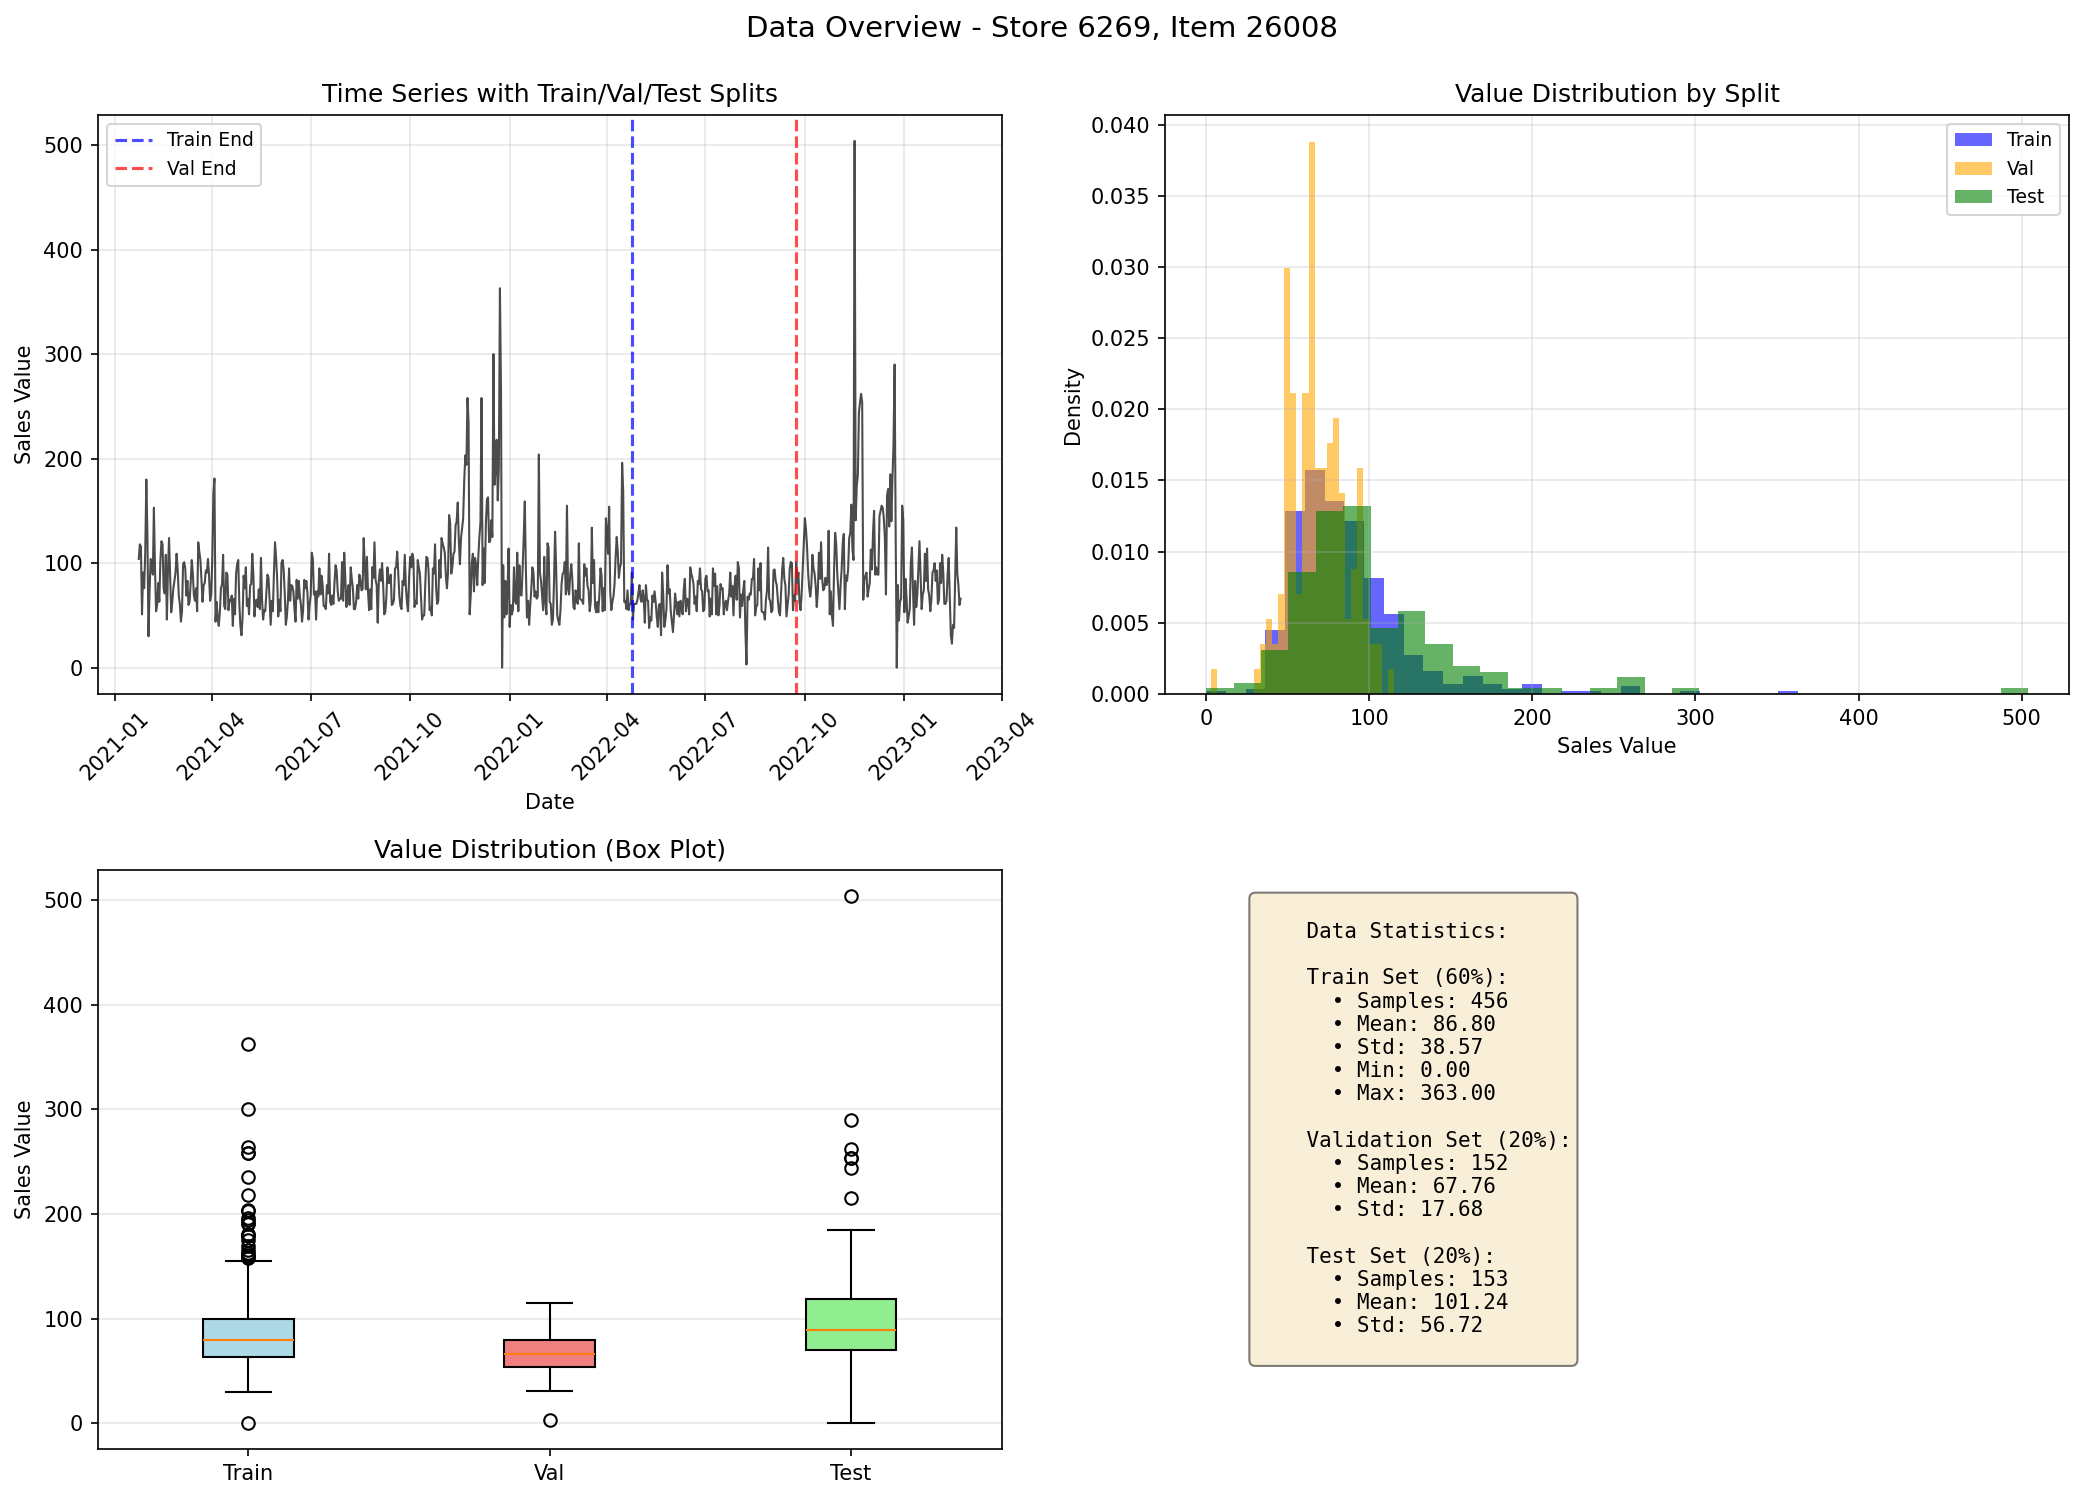


  Loss Curves.Png


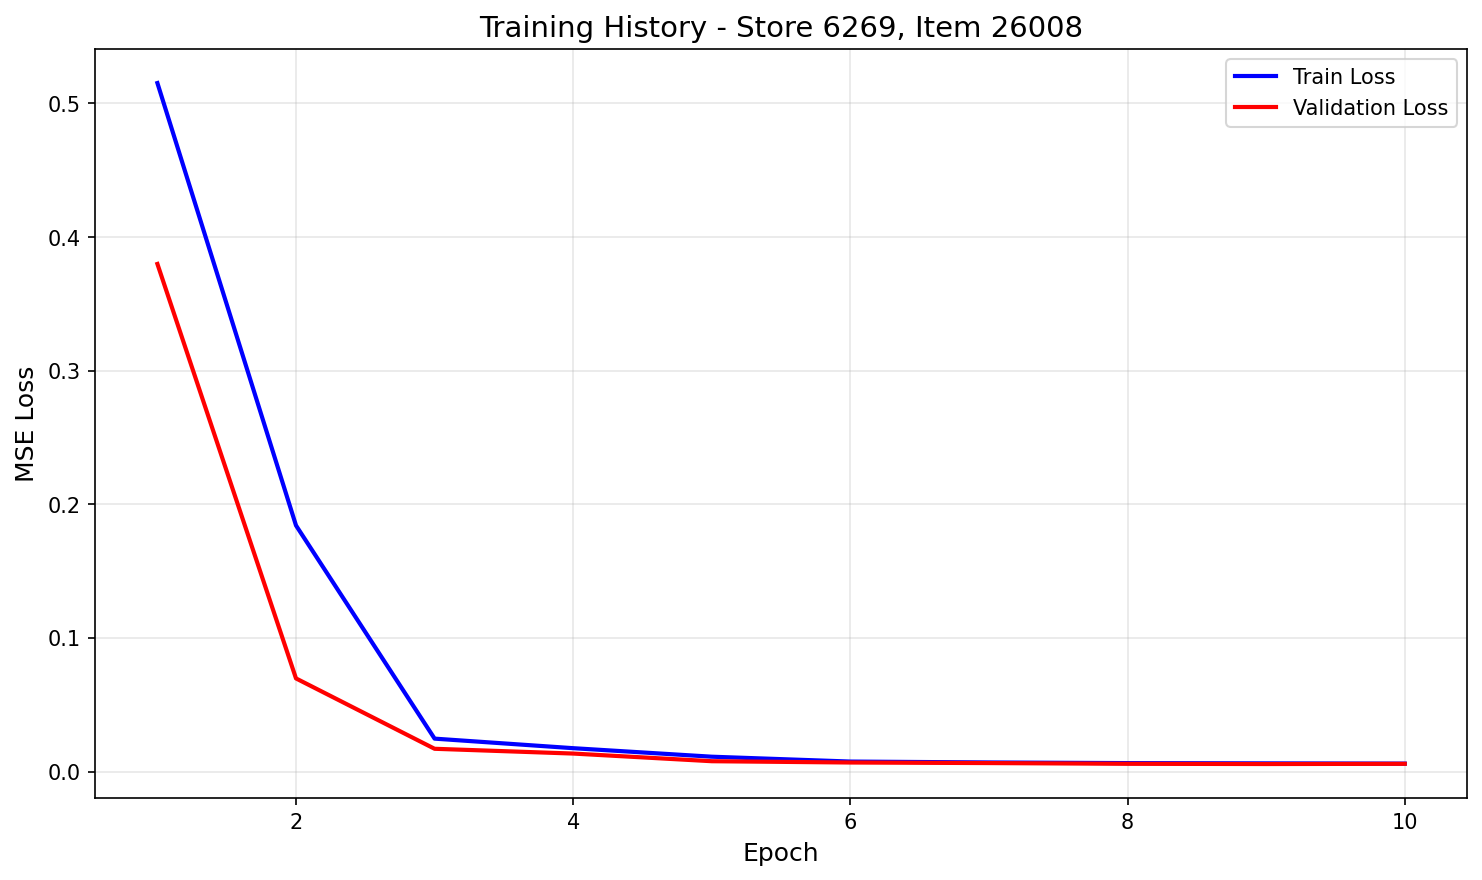


  Forecast Comparison.Png


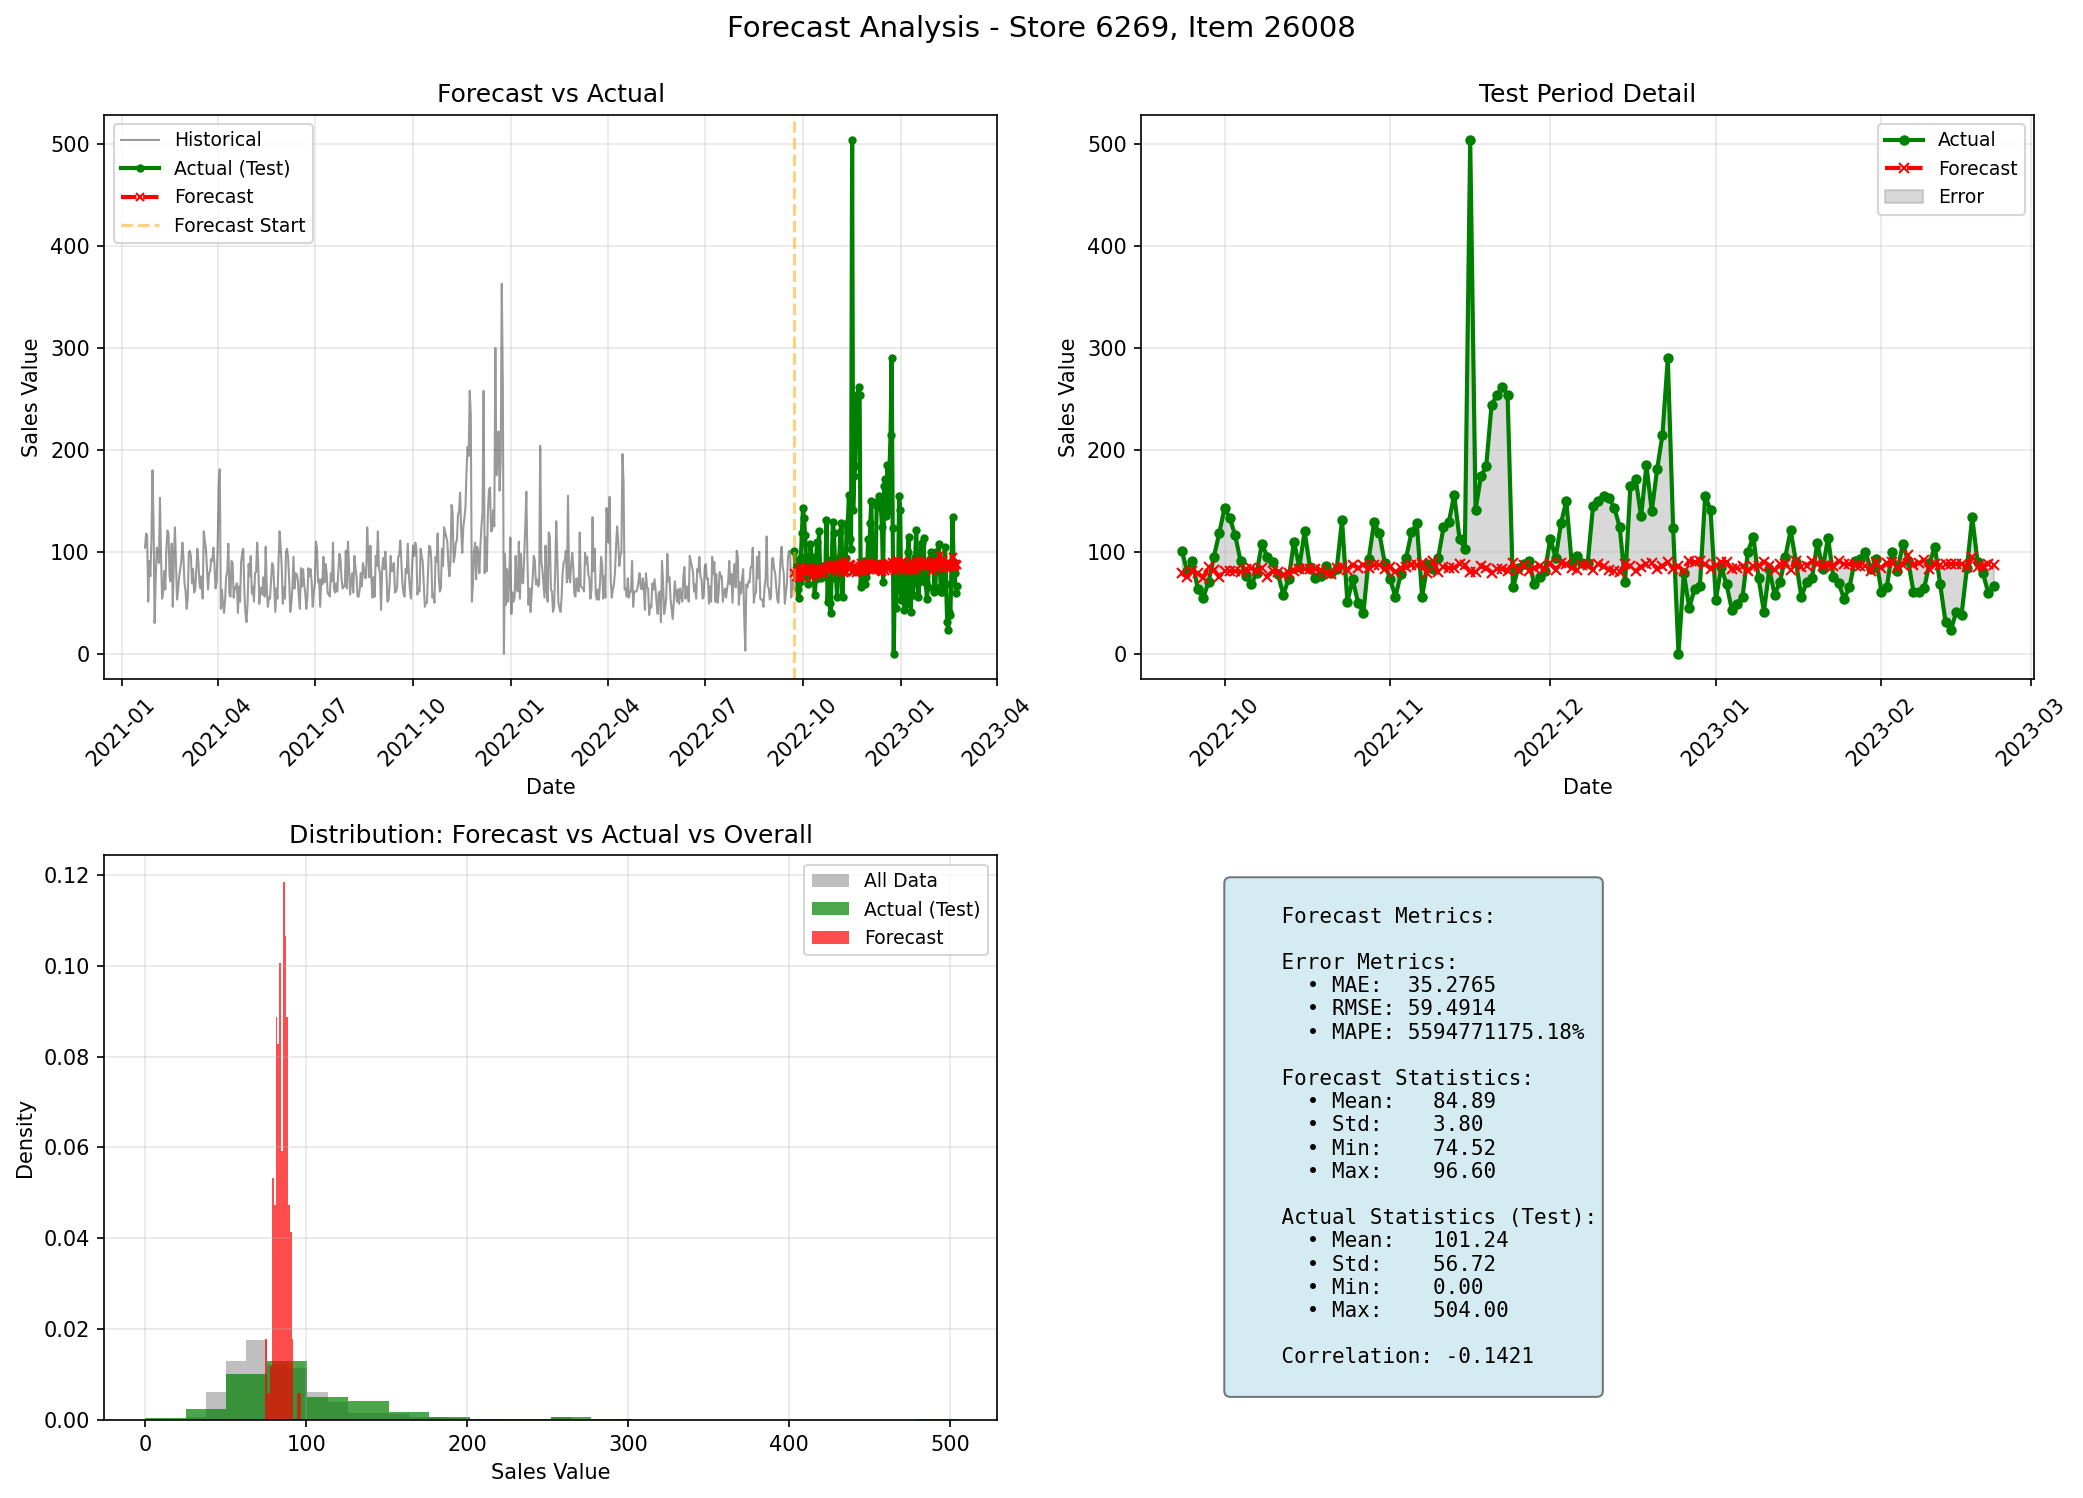

In [18]:


# View plots for the first trained item
if len(results) > 0:
    first_item = list(results.keys())[0]
    show_item_plots(first_item[0], first_item[1])
